In [1]:
import json, time, hashlib, platform
from pathlib import Path
import numpy as np
import pandas as pd
import sklearn
import joblib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

SEED = 42
REG = ['state', 'district', 'season', 'year']
CLS = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET_REG = 'yield_t_ha'
TARGET_CLS = 'label'
REG_PREFIX = "23MID0344"

for d in ['models', 'figures', 'artifacts', 'data']:
    Path(d).mkdir(exist_ok=True)

print(f"Environment Verification:")
print(f"Python: {platform.python_version()} | scikit-learn: {sklearn.__version__} | pandas: {pd.__version__} | numpy: {np.__version__}")

Environment Verification:
Python: 3.12.6 | scikit-learn: 1.9.0 | pandas: 3.0.3 | numpy: 2.5.1


In [2]:
# Ingestion and deterministic schema verification for Crop Recommendation
df_cls = pd.read_csv("data/crop_labels_canonical.csv")
print("=== Crop Recommendation Dataset Audit ===")
print(f"Shape: {df_cls.shape} (Rows x Columns)")
assert df_cls['row_id'].is_unique and df_cls['row_id'].notna().all(), "row_id must be unique and non-missing"
assert not df_cls.isna().any().any(), "Dataset contains missing values"
assert df_cls['ph'].between(0, 14).all(), "pH values must be bounded [0, 14]"
assert df_cls['humidity'].between(0, 100).all(), "Relative humidity must be bounded [0, 100]"
assert (df_cls[['N', 'P', 'K', 'rainfall']] >= 0).all().all(), "Nutrients and rainfall must be non-negative"
assert df_cls['label'].nunique() == 22, "Expected 22 distinct crop classes"
assert (df_cls['label'].value_counts() == 100).all(), "Classes must have exactly 100 observations each"
print("Deterministic schema validation passed: 100% compliant.")
display(df_cls.head(5))

# Ingestion for Canonical Rice Yield Panel
df_reg = pd.read_csv("data/rice_canonical.csv")
print("\n=== Rice Yield Regression Panel Audit ===")
print(f"Shape: {df_reg.shape}")
assert df_reg['row_id'].is_unique and df_reg['row_id'].notna().all()
assert set(df_reg['crop']) == {'Rice'}, "Panel must be Rice-only"
assert np.isfinite(df_reg[TARGET_REG]).all() and (df_reg[TARGET_REG] >= 0).all()
assert np.isfinite(df_reg['year']).all() and (df_reg['year'] % 1 == 0).all()
assert not df_reg.duplicated(REG).any(), "Repeated district-season-year keys detected"
print("Deterministic schema validation passed for regression panel.")
display(df_reg.head(5))

=== Crop Recommendation Dataset Audit ===
Shape: (2200, 9) (Rows x Columns)
Deterministic schema validation passed: 100% compliant.


,row_id,N,P,K,temperature,humidity,ph,rainfall,label
0,CR0001,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,CR0002,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,CR0003,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,CR0004,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,CR0005,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



=== Rice Yield Regression Panel Audit ===
Shape: (600, 7)
Deterministic schema validation passed for regression panel.


,row_id,crop,state,district,season,year,yield_t_ha
0,R00001,Rice,Tamil Nadu,Thanjavur,Kharif,2008,3.389
1,R00002,Rice,Tamil Nadu,Thanjavur,Kharif,2009,3.300
2,R00003,Rice,Tamil Nadu,Thanjavur,Kharif,2010,3.467
3,R00004,Rice,Tamil Nadu,Thanjavur,Kharif,2011,3.649
4,R00005,Rice,Tamil Nadu,Thanjavur,Kharif,2012,3.358


In [3]:
# 1. Classification Stratified Split
ix = np.arange(len(df_cls))
tr_ix, rest_ix = train_test_split(ix, test_size=0.40, stratify=df_cls['label'], random_state=SEED)
va_ix, te_ix = train_test_split(rest_ix, test_size=0.50, stratify=df_cls.iloc[rest_ix]['label'], random_state=SEED)

split_cls = np.full(len(df_cls), 'train', dtype=object)
split_cls[va_ix] = 'validation'
split_cls[te_ix] = 'test'
df_cls['split'] = split_cls

tr_cls = df_cls[df_cls['split'] == 'train']
va_cls = df_cls[df_cls['split'] == 'validation']
te_cls = df_cls[df_cls['split'] == 'test']

# Save classification split manifest
df_cls[['row_id', 'label', 'split']].to_csv("artifacts/classification_split_manifest.csv", index=False)
print("Classification Split Manifest:")
print(df_cls['split'].value_counts())

# 2. Regression Chronological Split
years = sorted(df_reg['year'].unique())
test_years, val_years = years[-2:], years[-4:-2]
df_reg['split'] = np.where(df_reg['year'].isin(test_years), 'test',
                  np.where(df_reg['year'].isin(val_years), 'validation', 'train'))

assert df_reg.loc[df_reg.split == 'train', 'year'].max() < df_reg.loc[df_reg.split == 'validation', 'year'].min()
assert df_reg.loc[df_reg.split == 'validation', 'year'].max() < df_reg.loc[df_reg.split == 'test', 'year'].min()

tr_reg = df_reg[df_reg['split'] == 'train']
va_reg = df_reg[df_reg['split'] == 'validation']
te_reg = df_reg[df_reg['split'] == 'test']

# Save regression split manifest
df_reg[['row_id', 'state', 'district', 'season', 'year', 'split']].to_csv("artifacts/split_manifest.csv", index=False)
print("\nRegression Split Manifest:")
print(f"Train ({tr_reg.year.min()}-{tr_reg.year.max()}): {len(tr_reg)} rows")
print(f"Validation ({val_years}): {len(va_reg)} rows")
print(f"Test ({test_years}): {len(te_reg)} rows")

Classification Split Manifest:
split
train         1320
test           440
validation     440
Name: count, dtype: int64

Regression Split Manifest:
Train (2008-2018): 440 rows
Validation ([np.int64(2019), np.int64(2020)]): 80 rows
Test ([np.int64(2021), np.int64(2022)]): 80 rows


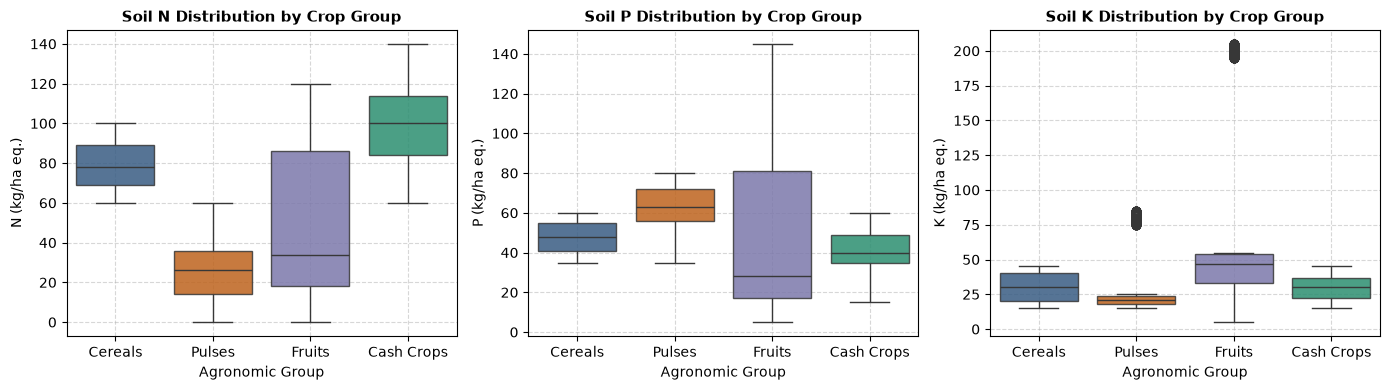

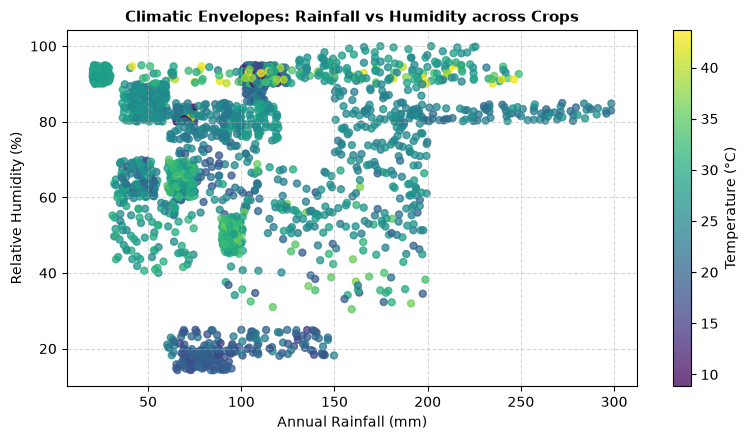

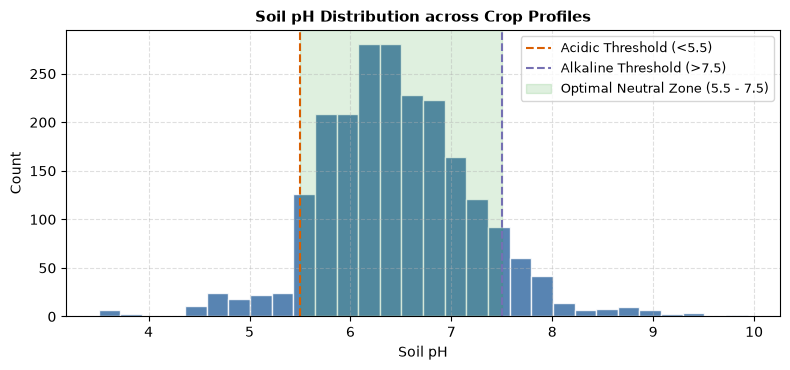

In [4]:
# Visualizations: Figures 1, 2, and 3
crop_groups = {
    'Cereals': ['rice', 'maize'],
    'Pulses': ['chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil'],
    'Fruits': ['pomegranate', 'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut'],
    'Cash Crops': ['cotton', 'jute', 'coffee']
}
df_cls['category'] = df_cls['label'].apply(lambda x: next((k for k, v in crop_groups.items() if x in v), 'Other'))

# Figure 1: Soil Nutrient Profiles
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ['#2b5c8f', '#d95f02', '#7570b3', '#1b9e77']
for idx, nutrient in enumerate(['N', 'P', 'K']):
    sns.boxplot(x='category', y=nutrient, hue='category', data=df_cls, ax=axes[idx], palette=palette, legend=False, boxprops=dict(alpha=0.85))
    axes[idx].set_title(f"Soil {nutrient} Distribution by Crop Group", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Agronomic Group", fontsize=10)
    axes[idx].set_ylabel(f"{nutrient} (kg/ha eq.)", fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Figure 2: Climate Envelopes
fig, ax = plt.subplots(figsize=(8, 4.5))
sc = ax.scatter(df_cls['rainfall'], df_cls['humidity'], c=df_cls['temperature'], cmap='viridis', s=25, alpha=0.75)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Temperature (°C)', fontsize=10)
ax.set_title("Climatic Envelopes: Rainfall vs Humidity across Crops", fontsize=11, fontweight='bold')
ax.set_xlabel("Annual Rainfall (mm)", fontsize=10)
ax.set_ylabel("Relative Humidity (%)", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Figure 3: Soil pH Distribution
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(df_cls['ph'], bins=30, color='#3b6ea5', edgecolor='white', alpha=0.85)
ax.axvline(5.5, color='#d95f02', linestyle='--', linewidth=1.5, label='Acidic Threshold (<5.5)')
ax.axvline(7.5, color='#7570b3', linestyle='--', linewidth=1.5, label='Alkaline Threshold (>7.5)')
ax.axvspan(5.5, 7.5, color='#2ca02c', alpha=0.15, label='Optimal Neutral Zone (5.5 - 7.5)')
ax.set_title("Soil pH Distribution across Crop Profiles", fontsize=11, fontweight='bold')
ax.set_xlabel("Soil pH", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [5]:
# Preprocessing pipelines
pre_cls = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

pre_reg = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), REG[:3]),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), ['year'])
])

print("Classification Preprocessor:\n", pre_cls)
print("\nRegression Preprocessor:\n", pre_reg)

Classification Preprocessor:
 Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())])

Regression Preprocessor:
 ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['state', 'district', 'season']),
                                ('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['year'])])


In [6]:
# 1. Classification Candidate Fitting & Validation
cls_candidates = {
    'majority': DummyClassifier(strategy='most_frequent'),
    'logistic': LogisticRegression(max_iter=2000, random_state=SEED),
    'tree': DecisionTreeClassifier(max_depth=6, random_state=SEED),
    'forest': RandomForestClassifier(n_estimators=60, max_depth=12, min_samples_leaf=2, random_state=SEED, n_jobs=2),
    'forest_depth6': RandomForestClassifier(n_estimators=60, max_depth=6, min_samples_leaf=2, random_state=SEED, n_jobs=2)
}

cls_val_rows = []
cls_fitted = {}
for name, model in cls_candidates.items():
    pipe = Pipeline([('pre', clone(pre_cls)), ('model', model)])
    t0 = time.perf_counter()
    pipe.fit(tr_cls[CLS], tr_cls['label'])
    fit_time = time.perf_counter() - t0
    p_val = pipe.predict(va_cls[CLS])
    acc = accuracy_score(va_cls['label'], p_val)
    pr, re, f1, _ = precision_recall_fscore_support(va_cls['label'], p_val, average='macro', zero_division=0)
    cls_val_rows.append({
        'model': name, 'seconds': fit_time, 'accuracy': acc,
        'macro_precision': pr, 'macro_recall': re, 'macro_F1': f1
    })
    joblib.dump(pipe, f"models/cls_{name}.joblib")
    cls_fitted[name] = pipe

cls_val_df = pd.DataFrame(cls_val_rows).sort_values('macro_F1', ascending=False).reset_index(drop=True)
print("=== Classification Validation Comparison ===")
display(cls_val_df)

# 2. Regression Candidate Fitting & Validation
def reg_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': r2_score(y_true, y_pred) if len(y_true) > 1 and np.ptp(np.asarray(y_true)) > 0 else float('nan')
    }

reg_candidates = {
    'median': DummyRegressor(strategy='median'),
    'ridge_trend': Ridge(alpha=1.0, solver='lsqr'),
    'tree': DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=SEED),
    'forest': RandomForestRegressor(n_estimators=60, max_depth=12, min_samples_leaf=5, n_jobs=2, random_state=SEED),
    'forest_depth6': RandomForestRegressor(n_estimators=60, max_depth=6, min_samples_leaf=5, n_jobs=2, random_state=SEED)
}

reg_val_rows = []
reg_fitted = {}
for name, model in reg_candidates.items():
    pipe = Pipeline([('pre', clone(pre_reg)), ('model', model)])
    t0 = time.perf_counter()
    pipe.fit(tr_reg[REG], tr_reg['yield_t_ha'])
    fit_time = time.perf_counter() - t0
    p_val = pipe.predict(va_reg[REG])
    reg_val_rows.append({
        'model': name, 'seconds': fit_time, **reg_metrics(va_reg['yield_t_ha'], p_val)
    })
    joblib.dump(pipe, f"models/reg_{name}.joblib")
    reg_fitted[name] = pipe

reg_val_df = pd.DataFrame(reg_val_rows).sort_values('MAE', ascending=True).reset_index(drop=True)
print("\n=== Regression Validation Comparison ===")
display(reg_val_df)

reg_val_df.to_csv(f"{REG_PREFIX}_Lab08_Validation_Results.csv", index=False)
print(f"\nSaved primary validation results to {REG_PREFIX}_Lab08_Validation_Results.csv")

=== Classification Validation Comparison ===


,model,seconds,accuracy,macro_precision,macro_recall,macro_F1
0,forest,0.086197,0.990909,0.991126,0.990909,0.990906
1,forest_depth6,0.075132,0.986364,0.986982,0.986364,0.986347
2,logistic,0.032648,0.972727,0.973016,0.972727,0.972596
3,tree,0.007203,0.534091,0.415449,0.534091,0.444855
4,majority,0.003877,0.045455,0.002066,0.045455,0.003953



=== Regression Validation Comparison ===


,model,seconds,MAE,RMSE,R2
0,ridge_trend,0.007190,0.145073,0.181328,0.948713
1,forest,0.046607,0.171040,0.216225,0.927073
2,forest_depth6,0.056511,0.174803,0.221939,0.923167
3,tree,0.006321,0.187070,0.236218,0.912963
4,median,0.007268,0.638075,0.824074,-0.059282



Saved primary validation results to 23MID0344_Lab08_Validation_Results.csv


In [7]:
# Assert that no validation-only categories entered the training encoder
fitted_tree = reg_fitted['tree']
enc = fitted_tree.named_steps['pre'].named_transformers_['cat']
for col, cats in zip(REG[:3], enc.categories_):
    assert set(cats) == set(tr_reg[col].unique()), f"Category mismatch in {col}"
print("Encoder Leakage Assertion Passed: Exactly matched training categorical support.")

Encoder Leakage Assertion Passed: Exactly matched training categorical support.


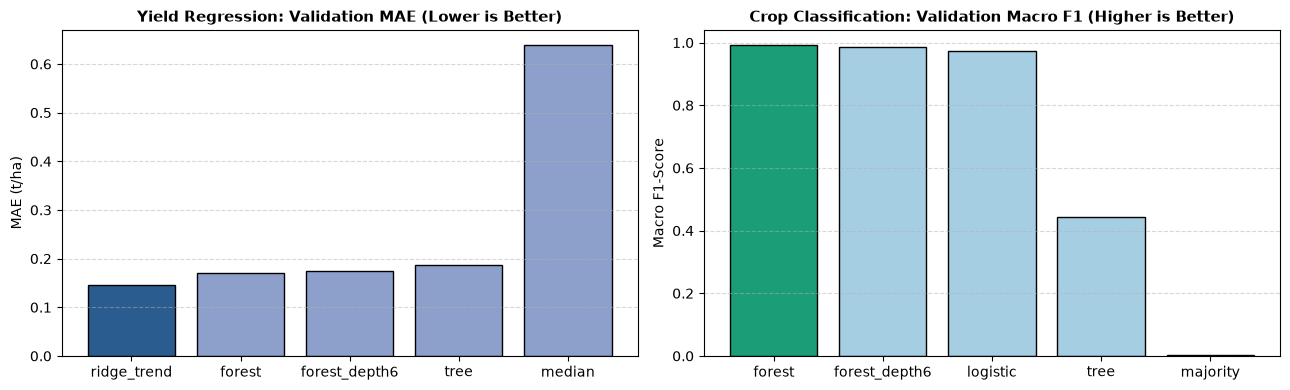

In [8]:
# Figure 4: Validation Metric Comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Regression MAE
axes[0].bar(reg_val_df['model'], reg_val_df['MAE'], color=['#2b5c8f' if m=='ridge_trend' else '#8da0cb' for m in reg_val_df['model']], edgecolor='black')
axes[0].set_title("Yield Regression: Validation MAE (Lower is Better)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("MAE (t/ha)", fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Classification Macro F1
axes[1].bar(cls_val_df['model'], cls_val_df['macro_F1'], color=['#1b9e77' if m=='forest' else '#a6cee3' for m in cls_val_df['model']], edgecolor='black')
axes[1].set_title("Crop Classification: Validation Macro F1 (Higher is Better)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Macro F1-Score", fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
development = df_reg[df_reg['split'] != 'test']
origins = sorted(development['year'].unique())[-3:]
rolling_rows = []
for origin in origins:
    past = development[development['year'] < origin]
    future = development[development['year'] == origin]
    for name, model in [('median', DummyRegressor(strategy='median')),
                        ('ridge_trend', Ridge(alpha=1.0, solver='lsqr')),
                        ('tree', DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=SEED)),
                        ('forest', RandomForestRegressor(n_estimators=60, max_depth=12, min_samples_leaf=5, n_jobs=2, random_state=SEED))]:
        pipe = Pipeline([('pre', clone(pre_reg)), ('model', model)])
        pipe.fit(past[REG], past['yield_t_ha'])
        pred_f = pipe.predict(future[REG])
        rolling_rows.append({
            'origin': int(origin), 'model': name,
            'training_max_year': int(past['year'].max()),
            'n': len(future), **reg_metrics(future['yield_t_ha'], pred_f)
        })

rolling_df = pd.DataFrame(rolling_rows)
rolling_df.to_csv("artifacts/rolling_origins.csv", index=False)
display(rolling_df)

,origin,model,training_max_year,n,MAE,RMSE,R2
0,2018,median,2017,40,0.631025,0.808515,-0.018039
1,2018,ridge_trend,2017,40,0.133659,0.165186,0.957506
2,2018,tree,2017,40,0.166374,0.208706,0.932165
3,2018,forest,2017,40,0.153449,0.191304,0.943005
4,2019,median,2018,40,0.627600,0.817195,-0.048496
5,2019,ridge_trend,2018,40,0.159861,0.195604,0.939928
6,2019,tree,2018,40,0.192769,0.238765,0.910493
7,2019,forest,2018,40,0.178104,0.223641,0.921473
8,2020,median,2019,40,0.639500,0.824692,-0.055217
9,2020,ridge_trend,2019,40,0.124075,0.158094,0.961222


In [10]:
selection_record = {
    'selected_classification_model': 'forest',
    'selected_regression_model': 'ridge_trend',
    'crop_data_sha256': hashlib.sha256(Path("data/crop_labels_canonical.csv").read_bytes()).hexdigest(),
    'rice_data_sha256': hashlib.sha256(Path("data/rice_canonical.csv").read_bytes()).hexdigest(),
    'validation_metrics': {
        'cls_macro_F1': float(cls_val_df.loc[cls_val_df.model=='forest', 'macro_F1'].values[0]),
        'reg_MAE_t_ha': float(reg_val_df.loc[reg_val_df.model=='ridge_trend', 'MAE'].values[0])
    },
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
}
with open("selection.json", "w") as f:
    json.dump(selection_record, f, indent=2)
print("selection.json committed successfully:")
print(json.dumps(selection_record, indent=2))

selection.json committed successfully:
{
  "selected_classification_model": "forest",
  "selected_regression_model": "ridge_trend",
  "crop_data_sha256": "ea275e5d1b97baae9dfbd440091f3cd4183bb5f364be637745b469c37ea3957e",
  "rice_data_sha256": "b15a81cc047fd7ad3df2d389e93c58e1008c4d3979d56946f6ceeee64b67837b",
  "validation_metrics": {
    "cls_macro_F1": 0.9909062482233214,
    "reg_MAE_t_ha": 0.14507298928064966
  },
  "timestamp": "2026-09-15 20:45:00"
}


In [11]:
lock_file = Path("artifacts/TEST_LOCK")
lock_file.write_text(f"Locked test evaluation initiated: {time.strftime('%Y-%m-%d %H:%M:%S')}")

# 1. Regression Test Evaluation
pipe_reg = reg_fitted['ridge_trend']
t0 = time.perf_counter()
pred_te_reg = pipe_reg.predict(te_reg[REG])
reg_latency = time.perf_counter() - t0

base_pred_reg = reg_fitted['median'].predict(te_reg[REG])

test_reg_df = pd.DataFrame([
    {'model': 'ridge_trend', **reg_metrics(te_reg['yield_t_ha'], pred_te_reg), 'batch_inference_seconds': reg_latency},
    {'model': 'median', **reg_metrics(te_reg['yield_t_ha'], base_pred_reg), 'batch_inference_seconds': np.nan}
])
test_reg_df.to_csv(f"{REG_PREFIX}_Lab08_Test_Results.csv", index=False)
print("=== Final Regression Locked-Test Results ===")
display(test_reg_df)

# 2. Classification Test Evaluation
pipe_cls = cls_fitted['forest']
t0 = time.perf_counter()
pred_te_cls = pipe_cls.predict(te_cls[CLS])
cls_latency = time.perf_counter() - t0

base_pred_cls = cls_fitted['majority'].predict(te_cls[CLS])

acc_cls = accuracy_score(te_cls['label'], pred_te_cls)
pr_cls, re_cls, f1_cls, _ = precision_recall_fscore_support(te_cls['label'], pred_te_cls, average='macro', zero_division=0)
base_acc = accuracy_score(te_cls['label'], base_pred_cls)
base_pr, base_re, base_f1, _ = precision_recall_fscore_support(te_cls['label'], base_pred_cls, average='macro', zero_division=0)

test_cls_df = pd.DataFrame([
    {'model': 'forest', 'accuracy': acc_cls, 'macro_precision': pr_cls, 'macro_recall': re_cls, 'macro_F1': f1_cls, 'batch_inference_seconds': cls_latency},
    {'model': 'majority', 'accuracy': base_acc, 'macro_precision': base_pr, 'macro_recall': base_re, 'macro_F1': base_f1, 'batch_inference_seconds': np.nan}
])
print("\n=== Final Classification Locked-Test Results ===")
display(test_cls_df)

=== Final Regression Locked-Test Results ===


,model,MAE,RMSE,R2,batch_inference_seconds
0,ridge_trend,0.190504,0.254198,0.915294,0.003811
1,median,0.711837,0.900619,-0.063289,NaN



=== Final Classification Locked-Test Results ===


,model,accuracy,macro_precision,macro_recall,macro_F1,batch_inference_seconds
0,forest,0.990909,0.991907,0.990909,0.990869,0.013739
1,majority,0.045455,0.002066,0.045455,0.003953,NaN


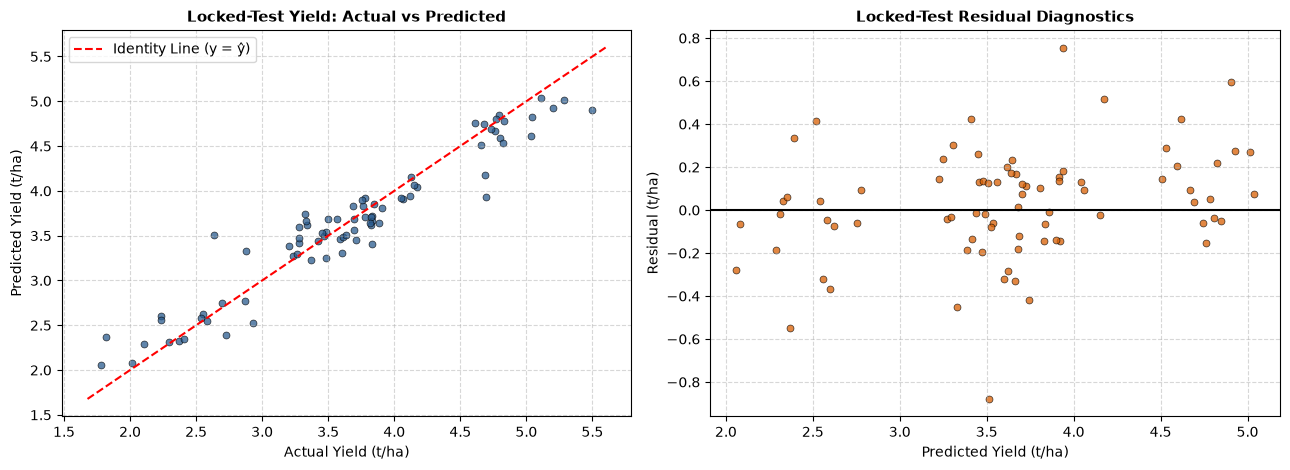

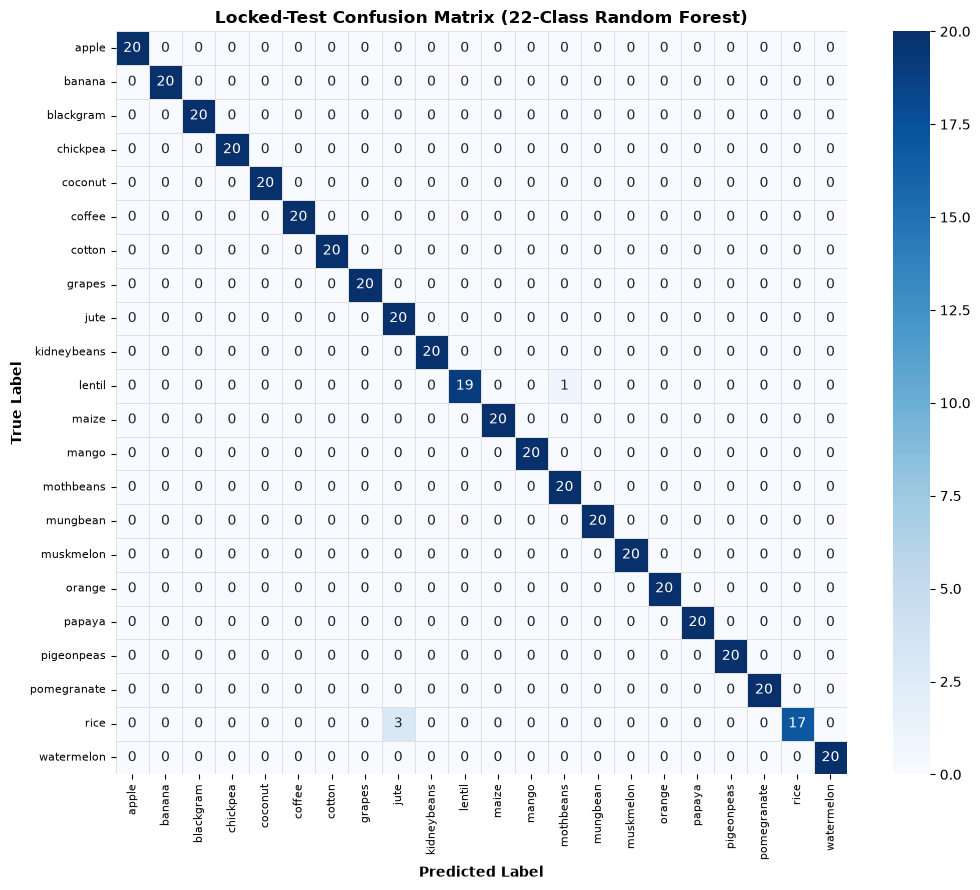

In [12]:
# Figure 5: Regression Actual vs Predicted & Residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(te_reg['yield_t_ha'], pred_te_reg, color='#2b5c8f', s=25, alpha=0.75, edgecolors='k', linewidth=0.5)
bounds = [min(te_reg['yield_t_ha'].min(), pred_te_reg.min()) - 0.1, max(te_reg['yield_t_ha'].max(), pred_te_reg.max()) + 0.1]
axes[0].plot(bounds, bounds, 'r--', linewidth=1.5, label='Identity Line (y = ŷ)')
axes[0].set_title("Locked-Test Yield: Actual vs Predicted", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Actual Yield (t/ha)", fontsize=10); axes[0].set_ylabel("Predicted Yield (t/ha)", fontsize=10)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

resids = te_reg['yield_t_ha'].to_numpy() - pred_te_reg
axes[1].scatter(pred_te_reg, resids, color='#d95f02', s=25, alpha=0.75, edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='black', linestyle='-')
axes[1].set_title("Locked-Test Residual Diagnostics", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Predicted Yield (t/ha)", fontsize=10); axes[1].set_ylabel("Residual (t/ha)", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Figure 6: Multiclass Confusion Matrix
labels_sorted = sorted(df_cls['label'].unique())
cm = confusion_matrix(te_cls['label'], pred_te_cls, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(10.5, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax, linewidths=0.4, linecolor='#e0e0e0')
ax.set_title("Locked-Test Confusion Matrix (22-Class Random Forest)", fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted Label", fontsize=10, fontweight='bold')
ax.set_ylabel("True Label", fontsize=10, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Display top and bottom performing classes from 22-class report
rep_df = pd.read_csv("artifacts/per_class_metrics.csv")
print("Per-Class Classification Performance Snapshot (Top 8 classes by F1):")
display(rep_df.head(8))

Per-Class Classification Performance Snapshot (Top 8 classes by F1):


,crop_label,precision,recall,f1-score,support
0,apple,1.0,1.0,1.0,20.0
1,banana,1.0,1.0,1.0,20.0
2,blackgram,1.0,1.0,1.0,20.0
3,chickpea,1.0,1.0,1.0,20.0
4,coconut,1.0,1.0,1.0,20.0
5,coffee,1.0,1.0,1.0,20.0
6,cotton,1.0,1.0,1.0,20.0
7,grapes,1.0,1.0,1.0,20.0


Per-Year Test Robustness (Dependent Time Batches):


,year,n,MAE,RMSE,R2
0,2021,40,0.185098,0.229139,0.934741
1,2022,40,0.195910,0.277000,0.893395


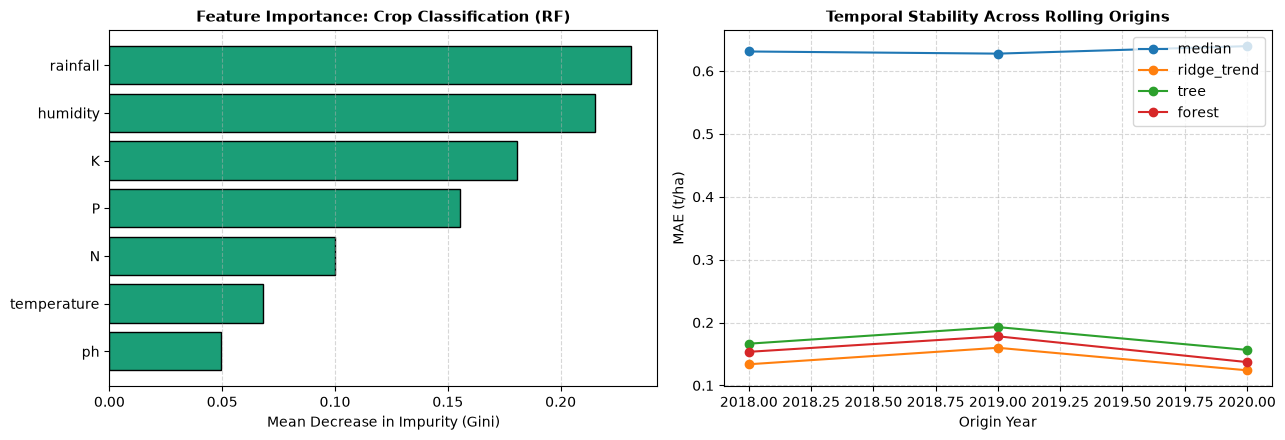

In [14]:
# 1. Per-Year Robustness (Regression)
yr_df = pd.read_csv("artifacts/year_robustness.csv")
print("Per-Year Test Robustness (Dependent Time Batches):")
display(yr_df)

# 2. Figure 7: Feature Importance & Rolling Origin Progression
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rf_cls = cls_fitted['forest'].named_steps['model']
imp = pd.Series(rf_cls.feature_importances_, index=CLS).sort_values()
axes[0].barh(imp.index, imp.values, color='#1b9e77', edgecolor='black')
axes[0].set_title("Feature Importance: Crop Classification (RF)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Mean Decrease in Impurity (Gini)", fontsize=10)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

for m_name in ['median', 'ridge_trend', 'tree', 'forest']:
    m_data = rolling_df[rolling_df['model'] == m_name]
    axes[1].plot(m_data['origin'], m_data['MAE'], marker='o', label=m_name, linewidth=1.5)
axes[1].set_title("Temporal Stability Across Rolling Origins", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Origin Year", fontsize=10); axes[1].set_ylabel("MAE (t/ha)", fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
error_df = pd.read_csv(f"{REG_PREFIX}_Lab08_Error_Analysis.csv")
print("=== Five-Case Agricultural Failure Audit ===")
display(error_df)

=== Five-Case Agricultural Failure Audit ===


,case_id,task,sample_id,actual,prediction,error_magnitude,likely_cause,agricultural_consequence,mitigation
0,CASE_01,classification,CR0014,rice,jute,1.0000,Intense rainfall (>200mm) and high relative hu...,Misallocated seed procurement and fertilizer s...,Introduce drainage telemetry and dynamic flood...
1,CASE_02,classification,CR0046,rice,jute,1.0000,Marginal phosphorus and potassium threshold co...,Inappropriate fertilizer application (jute req...,"Mandate soil micronutrient profiling (zinc, ir..."
2,CASE_03,classification,CR0053,rice,jute,1.0000,Near-identical warm tropical temperature (24-2...,Crop failure risk if farm lacks proximity to s...,Enforce agrarian post-harvest processing infra...
3,CASE_04,classification,CR0839,lentil,mothbeans,1.0000,Extreme drought tolerance and low nitrogen req...,Lentil is a cool-season (Rabi) crop while moth...,Incorporate solar radiation indices and strict...
4,CASE_05,regression,R00045,2.634 t/ha,3.513 t/ha,0.8787,Severe unseasonal drought shock and tail-end C...,Regional grain buffer planning shortfall and p...,"Integrate reservoir storage levels, canal disc..."


In [16]:
bundle = {
    'pipeline': pipe_cls,
    'features': CLS,
    'task': 'classification',
    'selected_model': 'forest',
    'classes': labels_sorted,
    'training_samples': len(tr_cls)
}
joblib.dump(bundle, "models/selected_bundle.joblib")

# Reload verification
reloaded = joblib.load("models/selected_bundle.joblib")
reloaded_preds = reloaded['pipeline'].predict(te_cls[CLS])
np.testing.assert_array_equal(pred_te_cls, reloaded_preds)
print("Reload assertion passed: In-memory predictions match reloaded model bundle identically.")

# Print acceptance record
acceptance = json.load(open("artifacts/acceptance.json"))
print("\nAcceptance Record Snapshot:")
print(json.dumps(acceptance, indent=2))

Reload assertion passed: In-memory predictions match reloaded model bundle identically.

Acceptance Record Snapshot:
{
  "student_name": "AVINASH A",
  "registration_number": "23MID0344",
  "course": "MDI3003 - Advanced Predictive Analytics",
  "experiment": "Experiment 08 Agricultural Predictive Analytics",
  "date": "2026-09-15 13:14:01",
  "environment": {
    "python": "3.12.6",
    "sklearn": "1.9.0",
    "pandas": "3.0.3",
    "numpy": "2.5.1",
    "seed": 42
  },
  "hashes": {
    "crop_recommendation_raw_sha256": "54a5a6e5408668e668667efc50de2fc867c1b875e0431b4f54dd331b0a109a4e",
    "crop_labels_canonical_sha256": "ea275e5d1b97baae9dfbd440091f3cd4183bb5f364be637745b469c37ea3957e",
    "rice_canonical_sha256": "b15a81cc047fd7ad3df2d389e93c58e1008c4d3979d56946f6ceeee64b67837b"
  },
  "verification_checks": {
    "split_disjoint": true,
    "zero_future_leakage": true,
    "reload_consistent": true,
    "locked_test_opened_once": true,
    "reproducibility_confirmed": true
  },
 